# 📊 Directional Options Scanner with Reversal Detection

## Version 1.8 - Multi-Timeframe Analysis

### Changelog
**v1.8** (Current)
- ✅ Added weekly timeframe confirmation
- ✅ Multi-timeframe trend alignment check (daily + weekly)
- ✅ Enhanced signal conviction with timeframe confluence
- ✅ Weekly RSI and moving average analysis
- ✅ Filters out counter-trend trades (daily uptrend + weekly downtrend = skip)
- ✅ Displays both timeframe contexts in output

**v1.7**
- ✅ Added price chart visualization with signal markers
- ✅ Plots price, MA20, MA50, RSI indicator panel
- ✅ Visual markers for reversal signals and entry points
- ✅ Configurable timezone support (default: US/Eastern)
- ✅ Fixed timestamp to show correct local time in journal

**v1.6**
- ✅ Added CSV trade journal export functionality
- ✅ Automatic logging of all scanner outputs with timestamps

**v1.5**
- ✅ Fixed volume distribution/accumulation logic

**v1.4.1**
- ✅ Fixed Greeks calculation using Black-Scholes model

**v1.4**
- ✅ Added Greeks display (Delta, Gamma, Theta, Vega)

**v1.3**
- ✅ Added minimum volume and open interest filters

**v1.2**
- ✅ Added comprehensive data validation for options chains

**v1.1**
- ✅ Enhanced RSI divergence detection with proper pivot point identification

**v1.0** (Initial Release)
- Initial scanner framework with basic reversal detection

In [27]:
# Code Cell 1: Library Imports (v1.7 - Added matplotlib & timezone)

import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
from scipy.stats import norm
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pytz import timezone as pytz_timezone

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*timezone.*')

# Configure pandas display for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ Libraries loaded successfully (v1.7)")

✓ Libraries loaded successfully (v1.7)


## Text Cell 2: Notebook Configuration

### Scanner Parameters
- **Tickers**: Symbols to scan (update this list for your watchlist)
- **Options Settings**: Minimum DTE (45 days), IV percentile threshold (50th)
- **Technical Levels**: RSI oversold/overbought thresholds, moving average periods

### Liquidity Filters (New in v1.3)
- **Minimum Volume**: 10 contracts traded today (prevents stale options)
- **Minimum Open Interest**: 50 contracts (ensures you can exit when needed)
- **Spread Warning**: Alert if bid/ask spread exceeds 20%
- **ATM Tolerance**: Only consider strikes within ±10% of current price

### Risk Management
- **Account Size**: Total capital allocated to options trading ($4,000 default)
- **Risk Per Trade**: 3-5% of account, adjusted by signal strength
- **Position Limits**: Max 4 open positions, 20% max allocation per trade
- **Exit Rules**: 50% stop loss, 100% profit target

### Reversal Detection Tuning
Fine-tune sensitivity for pattern recognition:
- **Divergence Lookback**: 14 bars for RSI pivot comparison
- **Volume Analysis**: 20-bar average baseline, 2x volume = climax
- **Extension Threshold**: 7% above MA20 = overextended
- **Breakout Validation**: 10-bar window for failed breakout detection

In [28]:
# Code Cell 2: Configuration Constants (v1.8 - Multi-Timeframe Added)

# ─────────────────────────────────────────────────────────────────────
# SCANNER CONFIGURATION
# ─────────────────────────────────────────────────────────────────────

# Tickers to scan
TICKERS = ["GOOGL", "XLF"]

# Options parameters
MIN_DTE = 45                    # Minimum days to expiration
IV_PCT_THRESHOLD = 50           # IV percentile warning level

# Technical indicator settings
RSI_OVERSOLD = 35               # RSI level for oversold condition
RSI_OVERBOUGHT = 65             # RSI level for overbought condition
MA_SHORT = 20                   # Short-term moving average period
MA_LONG = 50                    # Long-term moving average period

# ─────────────────────────────────────────────────────────────────────
# MULTI-TIMEFRAME ANALYSIS (NEW IN v1.8)
# ─────────────────────────────────────────────────────────────────────

ENABLE_MTF = True               # Set to False to disable multi-timeframe check
REQUIRE_MTF_ALIGNMENT = True    # Require daily + weekly trend agreement for signals
WEEKLY_MA_SHORT = 10            # Weekly equivalent of MA20 daily (10 weeks ≈ 50 days)
WEEKLY_MA_LONG = 20             # Weekly equivalent of MA50 daily (20 weeks ≈ 100 days)

# ─────────────────────────────────────────────────────────────────────
# LIQUIDITY FILTERS
# ─────────────────────────────────────────────────────────────────────

MIN_OPTION_VOLUME = 10          # Minimum contracts traded today
MIN_OPTION_OI = 50              # Minimum open interest
MAX_SPREAD_PCT = 20             # Warn if bid/ask spread > 20%
ATM_STRIKE_TOLERANCE = 0.10     # Filter to strikes within ±10% of price

# ─────────────────────────────────────────────────────────────────────
# RISK MANAGEMENT
# ─────────────────────────────────────────────────────────────────────

ACCOUNT_SIZE = 4000.00          # Total trading capital
RISK_PCT_MIN = 0.03             # Minimum risk per trade (3%)
RISK_PCT_MAX = 0.05             # Maximum risk per trade (5%)
MAX_POSITIONS = 4               # Maximum concurrent positions
STOP_LOSS_PCT = 0.50            # Exit at -50% on option premium
PROFIT_TARGET_PCT = 1.00        # Exit at +100% on option premium

# ─────────────────────────────────────────────────────────────────────
# REVERSAL DETECTION TUNING
# ─────────────────────────────────────────────────────────────────────

DIVERGENCE_LOOKBACK = 14        # Bars for RSI divergence analysis
VOLUME_AVG_PERIOD = 20          # Bars for volume baseline
CLIMAX_VOLUME_MULT = 2.0        # Volume threshold (2x avg = climax)
CLIMAX_MOVE_PCT = 0.03          # Single-bar move threshold (3%)
EXTENSION_PCT = 0.07            # Price extension threshold (7% above MA20)
BREAKOUT_LOOKBACK = 10          # Bars to validate breakout failure

# ─────────────────────────────────────────────────────────────────────
# TRADE JOURNAL
# ─────────────────────────────────────────────────────────────────────

ENABLE_JOURNAL = True           # Set to False to disable logging
JOURNAL_PATH = "trade_journal.csv"  # File path for journal

# ─────────────────────────────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────────────────────────────

ENABLE_CHARTS = True            # Set to False to disable chart display
CHART_PERIOD = 90               # Days of price history to display
TIMEZONE = 'US/Eastern'         # Your local timezone

print("✓ Configuration loaded (v1.8)")
print(f"  Scanning: {', '.join(TICKERS)}")
print(f"  Account: ${ACCOUNT_SIZE:,.2f} | Risk per trade: {RISK_PCT_MIN*100:.0f}%-{RISK_PCT_MAX*100:.0f}%")
print(f"  Multi-Timeframe: {'Enabled' if ENABLE_MTF else 'Disabled'} | Require Alignment: {REQUIRE_MTF_ALIGNMENT}")
print(f"  Liquidity: Min volume {MIN_OPTION_VOLUME}, Min OI {MIN_OPTION_OI}")
print(f"  Journal: {'Enabled' if ENABLE_JOURNAL else 'Disabled'} → {JOURNAL_PATH if ENABLE_JOURNAL else 'N/A'}")
print(f"  Charts: {'Enabled' if ENABLE_CHARTS else 'Disabled'} | Timezone: {TIMEZONE}")

✓ Configuration loaded (v1.8)
  Scanning: GOOGL, XLF
  Account: $4,000.00 | Risk per trade: 3%-5%
  Multi-Timeframe: Enabled | Require Alignment: True
  Liquidity: Min volume 10, Min OI 50
  Journal: Enabled → trade_journal.csv
  Charts: Enabled | Timezone: US/Eastern


## Text Cell 3: Technical Indicators

### Indicator Functions
These functions calculate the core technical metrics used for signal generation:

**RSI (Relative Strength Index)**: Measures momentum on 0-100 scale. Values below 35 suggest oversold conditions (potential buy), above 65 suggest overbought (potential sell).

**Historical Volatility**: Annualized standard deviation of log returns, used as proxy for options pricing volatility when IV data is incomplete.

**IV Percentile**: Ranks current implied volatility against 1-year history. High percentile (>50th) warns that options are expensive relative to historical norms.

**Trend Classification**: Compares price to MA20 and MA50 to determine market structure (UPTREND, DOWNTREND, or MIXED).

In [29]:
# Code Cell 3: Indicator Functions

def compute_rsi(series, period=14):
    """
    Calculate RSI using standard Wilder's smoothing method.
    Returns: pandas Series with RSI values (0-100)
    """
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / loss.replace(0, np.nan)  # Prevent division by zero
    return 100 - (100 / (1 + rs))


def compute_historical_volatility(close, window=30):
    """
    Calculate annualized historical volatility.
    Returns: pandas Series with volatility as percentage
    """
    log_ret = np.log(close / close.shift(1))
    return log_ret.rolling(window).std() * np.sqrt(252) * 100


def compute_iv_percentile(series, current):
    """
    Rank current value against historical distribution.
    Returns: Percentile rank (0-100) or None if insufficient data
    """
    if len(series) < 20:
        return None
    return round((series < current).mean() * 100, 1)


def get_trend(price, ma_s, ma_l):
    """
    Classify trend based on price vs moving averages.
    Returns: "UPTREND", "DOWNTREND", or "MIXED"
    """
    if price > ma_s > ma_l:
        return "UPTREND"
    elif price < ma_s < ma_l:
        return "DOWNTREND"
    return "MIXED"


print("✓ Indicator functions defined")

✓ Indicator functions defined


In [30]:
# Code Cell 3A: Black-Scholes Greeks Calculator (NEW IN v1.4.1)

def calculate_greeks(option_type, stock_price, strike, time_to_expiry, risk_free_rate, volatility):
    """
    Calculate option Greeks using Black-Scholes model.

    Args:
        option_type: 'call' or 'put'
        stock_price: Current stock price
        strike: Option strike price
        time_to_expiry: Time to expiration in years
        risk_free_rate: Annual risk-free rate (default 0.05 for 5%)
        volatility: Implied volatility as decimal (e.g., 0.30 for 30%)

    Returns:
        Dictionary with delta, gamma, theta, vega
    """

    # Handle edge cases
    if time_to_expiry <= 0:
        # Option expired
        if option_type == 'call':
            delta = 1.0 if stock_price > strike else 0.0
        else:
            delta = -1.0 if stock_price < strike else 0.0
        return {'delta': delta, 'gamma': 0, 'theta': 0, 'vega': 0}

    if volatility <= 0 or stock_price <= 0 or strike <= 0:
        return {'delta': np.nan, 'gamma': np.nan, 'theta': np.nan, 'vega': np.nan}

    # Black-Scholes calculations
    d1 = (np.log(stock_price / strike) + (risk_free_rate + 0.5 * volatility**2) * time_to_expiry) / (volatility * np.sqrt(time_to_expiry))
    d2 = d1 - volatility * np.sqrt(time_to_expiry)

    # Calculate Greeks
    if option_type.lower() == 'call':
        delta = norm.cdf(d1)
    else:  # put
        delta = -norm.cdf(-d1)

    # Gamma (same for calls and puts)
    gamma = norm.pdf(d1) / (stock_price * volatility * np.sqrt(time_to_expiry))

    # Theta (daily decay)
    if option_type.lower() == 'call':
        theta = (-(stock_price * norm.pdf(d1) * volatility) / (2 * np.sqrt(time_to_expiry))
                 - risk_free_rate * strike * np.exp(-risk_free_rate * time_to_expiry) * norm.cdf(d2)) / 365
    else:  # put
        theta = (-(stock_price * norm.pdf(d1) * volatility) / (2 * np.sqrt(time_to_expiry))
                 + risk_free_rate * strike * np.exp(-risk_free_rate * time_to_expiry) * norm.cdf(-d2)) / 365

    # Vega (sensitivity to 1% change in IV)
    vega = stock_price * norm.pdf(d1) * np.sqrt(time_to_expiry) / 100

    return {
        'delta': delta,
        'gamma': gamma,
        'theta': theta,
        'vega': vega
    }


def get_greeks_for_option(option_row, stock_price, time_to_expiry, option_type):
    """
    Extract or calculate Greeks for an option.

    Args:
        option_row: DataFrame row from yfinance option chain
        stock_price: Current stock price
        time_to_expiry: Years to expiration
        option_type: 'call' or 'put'

    Returns:
        Dictionary with delta, gamma, theta, vega
    """
    # Try to get Greeks from yfinance first
    delta = option_row.get('delta', np.nan)
    gamma = option_row.get('gamma', np.nan)
    theta = option_row.get('theta', np.nan)
    vega = option_row.get('vega', np.nan)

    # If any are missing, calculate them ourselves
    if np.isnan(delta) or np.isnan(gamma) or np.isnan(theta) or np.isnan(vega):
        strike = option_row.get('strike', 0)
        iv = option_row.get('impliedVolatility', 0)

        if iv > 0 and strike > 0 and time_to_expiry > 0:
            # Use 5% risk-free rate as default (adjust based on current rates)
            calculated = calculate_greeks(option_type, stock_price, strike, time_to_expiry, 0.05, iv)

            # Use calculated values if yfinance didn't provide them
            if np.isnan(delta):
                delta = calculated['delta']
            if np.isnan(gamma):
                gamma = calculated['gamma']
            if np.isnan(theta):
                theta = calculated['theta']
            if np.isnan(vega):
                vega = calculated['vega']

    return {
        'delta': delta,
        'gamma': gamma,
        'theta': theta,
        'vega': vega
    }


print("✓ Greeks calculator defined (v1.4.1)")

✓ Greeks calculator defined (v1.4.1)


## Text Cell 3B: Multi-Timeframe Analysis

### Purpose
Multi-timeframe analysis compares daily and weekly charts to filter out counter-trend trades. When both timeframes agree on direction, conviction increases. When they conflict, the trade is flagged or filtered out.

### How It Works
**Daily Timeframe**: Primary analysis using 20/50 moving averages
**Weekly Timeframe**: Confirmation using 10/20 week moving averages (≈50/100 day equivalents)

### Alignment Rules
**High Confidence (Boost conviction)**:
- CALL: Daily uptrend + Weekly uptrend
- PUT: Daily downtrend + Weekly downtrend

**Moderate Confidence (Accept)**:
- CALL: Daily uptrend + Weekly mixed
- PUT: Daily downtrend + Weekly mixed

**Conflict (Filter out if REQUIRE_MTF_ALIGNMENT = True)**:
- CALL signal but weekly is in downtrend
- PUT signal but weekly is in uptrend

### Benefits
- Filters out counter-trend trades (lower win rate)
- Increases conviction when timeframes align
- Reduces whipsaw trades
- Better risk/reward on aligned setups

### Configuration
- `ENABLE_MTF = True/False` - Turn multi-timeframe on/off
- `REQUIRE_MTF_ALIGNMENT = True/False` - Strict filtering vs warning only

In [31]:
# Code Cell 3B: Multi-Timeframe Analysis (NEW IN v1.8)

def analyze_weekly_timeframe(ticker_obj):
    """
    Analyze weekly chart for trend confirmation.

    Returns:
        Dictionary with weekly analysis data or None if error
    """
    try:
        # Fetch weekly data (2 years for enough weekly bars)
        weekly_hist = ticker_obj.history(period="2y", interval="1wk")

        if weekly_hist.empty or len(weekly_hist) < WEEKLY_MA_LONG + 5:
            return None

        weekly_close = weekly_hist['Close']
        weekly_price = round(weekly_close.iloc[-1], 2)

        # Calculate weekly indicators
        weekly_rsi_s = compute_rsi(weekly_close)
        weekly_rsi = round(weekly_rsi_s.iloc[-1], 1)

        weekly_ma_s = weekly_close.rolling(WEEKLY_MA_SHORT).mean()
        weekly_ma_l = weekly_close.rolling(WEEKLY_MA_LONG).mean()

        weekly_ma_s_current = weekly_ma_s.iloc[-1]
        weekly_ma_l_current = weekly_ma_l.iloc[-1]

        weekly_trend = get_trend(weekly_price, weekly_ma_s_current, weekly_ma_l_current)

        weekly_p_ma_s = round((weekly_price - weekly_ma_s_current) / weekly_ma_s_current * 100, 2)
        weekly_p_ma_l = round((weekly_price - weekly_ma_l_current) / weekly_ma_l_current * 100, 2)

        return {
            'price': weekly_price,
            'rsi': weekly_rsi,
            'trend': weekly_trend,
            'ma_short': round(weekly_ma_s_current, 2),
            'ma_long': round(weekly_ma_l_current, 2),
            'pct_from_ma_short': weekly_p_ma_s,
            'pct_from_ma_long': weekly_p_ma_l
        }

    except Exception as e:
        print(f"   ⚠ Weekly timeframe analysis failed: {e}")
        return None


def check_timeframe_alignment(daily_trend, weekly_trend, signal_direction):
    """
    Check if daily and weekly timeframes are aligned with signal direction.

    Args:
        daily_trend: Daily trend classification
        weekly_trend: Weekly trend classification
        signal_direction: "BUY CALL" or "BUY PUT"

    Returns:
        (is_aligned, confidence_boost, description)
    """
    if not ENABLE_MTF:
        return True, 0, "Multi-timeframe disabled"

    # Determine if trends align
    both_up = (daily_trend == "UPTREND" and weekly_trend == "UPTREND")
    both_down = (daily_trend == "DOWNTREND" and weekly_trend == "DOWNTREND")
    daily_up_weekly_mixed = (daily_trend == "UPTREND" and weekly_trend == "MIXED")
    daily_down_weekly_mixed = (daily_trend == "DOWNTREND" and weekly_trend == "MIXED")

    # Check alignment with signal direction
    if signal_direction == "BUY CALL":
        # Bullish signal - want uptrends
        if both_up:
            return True, 1, "✓ Daily & weekly both uptrending - HIGH CONFIDENCE"
        elif daily_up_weekly_mixed:
            return True, 0, "✓ Daily uptrend, weekly mixed - MODERATE CONFIDENCE"
        elif daily_trend == "MIXED" and weekly_trend == "UPTREND":
            return True, 0, "✓ Weekly uptrend supporting - MODERATE CONFIDENCE"
        elif daily_trend == "UPTREND" and weekly_trend == "DOWNTREND":
            return False, -1, "⚠ CONFLICT: Daily up but weekly down - COUNTER-TREND TRADE"
        else:
            return False, 0, "⚠ Weak alignment - consider passing"

    else:  # BUY PUT
        # Bearish signal - want downtrends
        if both_down:
            return True, 1, "✓ Daily & weekly both downtrending - HIGH CONFIDENCE"
        elif daily_down_weekly_mixed:
            return True, 0, "✓ Daily downtrend, weekly mixed - MODERATE CONFIDENCE"
        elif daily_trend == "MIXED" and weekly_trend == "DOWNTREND":
            return True, 0, "✓ Weekly downtrend supporting - MODERATE CONFIDENCE"
        elif daily_trend == "DOWNTREND" and weekly_trend == "UPTREND":
            return False, -1, "⚠ CONFLICT: Daily down but weekly up - COUNTER-TREND TRADE"
        else:
            return False, 0, "⚠ Weak alignment - consider passing"


print("✓ Multi-timeframe functions defined (v1.8)")

✓ Multi-timeframe functions defined (v1.8)


## Text Cell 4: Reversal Detection Framework

### Pattern Recognition Logic
The scanner identifies potential trend reversals by detecting multiple confirming signals. No single indicator is sufficient; edge comes from confluence.

**RSI Divergence**: Price makes new high while RSI makes lower high (bearish), or price makes new low while RSI makes higher low (bullish). Suggests momentum is diverging from price action.

**Volume Signals (Corrected in v1.5)**:
- *Distribution*: Down days on heavy volume (institutions selling into strength) - **BEARISH**
- *Selling Pressure*: Multiple down days with above-average volume (sustained selling) - **BEARISH**
- *Accumulation*: Up days on heavy volume (institutions buying weakness) - **BULLISH**
- *Weak Rally*: Up days on low volume (retail buying, unsustainable) - **BEARISH**

**Why Volume Matters**: Professional traders (institutions, market makers) move size and create volume. When price rises on low volume, it suggests retail participation without institutional support - often precedes reversals. When price falls on high volume, institutions are distributing (selling) - bearish signal.

**Climax Detection**: Massive single-bar move on huge volume after extended run — often marks exhaustion before reversal.

**Failed Breakout**: Price pushes to new high then reverses below prior resistance, trapping late buyers.

**MA Breakdown**: Price closes below moving average for 2+ consecutive bars after being above, confirming loss of support.

### Conviction Scoring
Multiple confirming signals increase conviction:
- **WATCH** (2 signals): Early warning, monitor closely
- **MODERATE** (3 signals): Actionable setup, standard position size
- **HIGH** (4+ signals): High-conviction setup, maximum position size

## Text Cell 4A: Understanding Option Greeks

### What Are Greeks?
Greeks measure how option prices change relative to various factors. Understanding them is critical for managing risk.

**Delta (Δ)**: Rate of price change per $1 move in underlying
- Calls: 0 to 1.00 (ATM ≈ 0.50, meaning option moves $0.50 per $1 stock move)
- Puts: 0 to -1.00 (ATM ≈ -0.50, meaning option moves $0.50 per $1 stock move down)
- Higher delta = more directional exposure = closer to stock movement

**Theta (Θ)**: Daily time decay (always negative for long options)
- Shows how much option loses in value each day, all else equal
- Accelerates as expiration approaches
- Example: Theta of -$0.15 means losing $15/day per contract

**Vega (ν)**: Sensitivity to 1% change in implied volatility
- Positive for long options (benefit from IV increase)
- Example: Vega of 0.10 means +$10 per contract if IV rises 1%
- Important during earnings or events that spike IV

**Gamma (Γ)**: Rate of change in Delta
- Measures how fast Delta changes as stock moves
- Highest for ATM options
- High gamma = Delta changes rapidly (more risk/reward)

### Practical Use
- **High Theta**: Pay attention to time decay, may need quick move
- **High Vega**: Vulnerable to IV crush, avoid pre-earnings
- **Low Delta (<0.30)**: Option may not move much even if direction right
- **High Delta (>0.70)**: Acts almost like stock, less leverage

In [32]:
# Code Cell 4: Reversal Detection Functions (v1.5 - Volume Logic Fixed)

def detect_rsi_divergence(close, rsi_series, lookback=DIVERGENCE_LOOKBACK):
    """
    Detect RSI divergence patterns using proper pivot point identification.
    Bearish: price swing high > prior swing high, RSI swing high < prior RSI high
    Bullish: price swing low < prior swing low, RSI swing low > prior RSI low
    Returns: List of detected divergence types
    """
    results = []
    if len(close) < lookback + 5:
        return results

    # Find swing highs (for bearish divergence detection)
    swing_highs_price = []
    swing_highs_rsi = []

    for i in range(-lookback, -2):  # Stop at -2 to have room for comparison
        idx = len(close) + i
        if idx <= 0 or idx >= len(close) - 1:
            continue

        # Price makes local high (higher than bars on both sides)
        if close.iloc[idx] > close.iloc[idx-1] and close.iloc[idx] > close.iloc[idx+1]:
            swing_highs_price.append((i, close.iloc[idx]))
            swing_highs_rsi.append((i, rsi_series.iloc[idx]))

    # Check for bearish divergence (need at least 2 swing highs)
    if len(swing_highs_price) >= 2:
        # Compare most recent swing high to prior swing high
        latest_price = swing_highs_price[-1][1]
        prior_price = swing_highs_price[-2][1]
        latest_rsi = swing_highs_rsi[-1][1]
        prior_rsi = swing_highs_rsi[-2][1]

        # Bearish divergence: price higher high + RSI lower high
        if latest_price > prior_price and latest_rsi < prior_rsi:
            if rsi_series.iloc[-1] > 50:  # Confirm we're in overbought territory
                results.append("BEARISH_DIVERGENCE")

    # Find swing lows (for bullish divergence detection)
    swing_lows_price = []
    swing_lows_rsi = []

    for i in range(-lookback, -2):
        idx = len(close) + i
        if idx <= 0 or idx >= len(close) - 1:
            continue

        # Price makes local low (lower than bars on both sides)
        if close.iloc[idx] < close.iloc[idx-1] and close.iloc[idx] < close.iloc[idx+1]:
            swing_lows_price.append((i, close.iloc[idx]))
            swing_lows_rsi.append((i, rsi_series.iloc[idx]))

    # Check for bullish divergence (need at least 2 swing lows)
    if len(swing_lows_price) >= 2:
        # Compare most recent swing low to prior swing low
        latest_price = swing_lows_price[-1][1]
        prior_price = swing_lows_price[-2][1]
        latest_rsi = swing_lows_rsi[-1][1]
        prior_rsi = swing_lows_rsi[-2][1]

        # Bullish divergence: price lower low + RSI higher low
        if latest_price < prior_price and latest_rsi > prior_rsi:
            if rsi_series.iloc[-1] < 50:  # Confirm we're in oversold territory
                results.append("BULLISH_DIVERGENCE")

    return results


def detect_volume_signals(close, volume, avg_period=VOLUME_AVG_PERIOD):
    """
    Analyze price/volume relationship for institutional activity.

    CORRECTED LOGIC (v1.5):
    - Distribution: DOWN days on HEAVY volume = institutions selling (bearish)
    - Accumulation: UP days on HEAVY volume = institutions buying (bullish)
    - Weak Rally: UP days on LOW volume = unsustainable retail buying (bearish)
    - Selling Pressure: Multiple down days with heavy volume (bearish)

    Returns: Dictionary of detected volume signals with details
    """
    if len(close) < avg_period + 3:
        return {}

    avg_vol = volume.rolling(avg_period).mean()
    recent_n = 5  # Analyze last 5 bars
    price_ch = close.diff()

    up_days = price_ch.iloc[-recent_n:] > 0
    down_days = price_ch.iloc[-recent_n:] < 0
    vol_recent = volume.iloc[-recent_n:]
    avg_recent = avg_vol.iloc[-recent_n:]

    signals = {}

    # ──────────────────────────────────────────────────────────────
    # BEARISH SIGNALS
    # ──────────────────────────────────────────────────────────────

    # Distribution: DOWN days on HEAVY volume (institutions selling)
    down_vol_heavy = (down_days & (vol_recent > avg_recent * 1.3)).sum()
    if down_vol_heavy >= 3:
        signals["DISTRIBUTION"] = f"Down days on heavy volume ({down_vol_heavy}/5 bars) - institutions selling"

    # Selling Pressure: Any down movement with sustained high volume
    selling_pressure = (down_days & (vol_recent > avg_recent * 1.2)).sum()
    if selling_pressure >= 3 and "DISTRIBUTION" not in signals:
        signals["SELLING_PRESSURE"] = f"Sustained selling on volume ({selling_pressure}/5 bars)"

    # Weak Rally: UP days on LOW volume (retail buying, no institutional support)
    up_vol_weak = (up_days & (vol_recent < avg_recent * 0.75)).sum()
    if up_vol_weak >= 3:
        signals["WEAK_RALLY"] = f"Up days on weak volume ({up_vol_weak}/5 bars) - unsustainable"

    # ──────────────────────────────────────────────────────────────
    # BULLISH SIGNALS
    # ──────────────────────────────────────────────────────────────

    # Accumulation: UP days on HEAVY volume (institutions buying)
    up_vol_strong = (up_days & (vol_recent > avg_recent * 1.3)).sum()
    if up_vol_strong >= 3:
        signals["ACCUMULATION"] = f"Up days on heavy volume ({up_vol_strong}/5 bars) - institutions buying"

    # Alternative accumulation: Down days on LOW volume (weak selling, support)
    down_vol_light = (down_days & (vol_recent < avg_recent * 0.75)).sum()
    if down_vol_light >= 3 and not signals:  # Only if no other signals
        signals["BUYING_SUPPORT"] = f"Down days on light volume ({down_vol_light}/5 bars) - lack of selling"

    return signals


def detect_climax(close, volume, avg_period=VOLUME_AVG_PERIOD):
    """
    Detect climax top: large move on huge volume (exhaustion signal).
    Returns: (bool, detail_string)
    """
    if len(close) < avg_period + 2:
        return False, ""

    avg_vol = volume.rolling(avg_period).mean().iloc[-1]
    last_vol = volume.iloc[-1]
    last_move = abs((close.iloc[-1] - close.iloc[-2]) / close.iloc[-2])
    is_up_bar = close.iloc[-1] > close.iloc[-2]

    if (is_up_bar
        and last_vol > avg_vol * CLIMAX_VOLUME_MULT
        and last_move > CLIMAX_MOVE_PCT):
        detail = f"Bar up {last_move*100:.1f}% on {last_vol/avg_vol:.1f}x avg volume"
        return True, detail

    return False, ""


def detect_failed_breakout(close, lookback=BREAKOUT_LOOKBACK):
    """
    Detect failed breakout: new high made, then price reversed below prior resistance.
    Returns: (bool, detail_string)
    """
    if len(close) < lookback + 3:
        return False, ""

    window = close.iloc[-(lookback+3):]
    prior_high = window.iloc[:-3].max()
    recent_high = window.iloc[-3:].max()
    current = close.iloc[-1]

    if recent_high > prior_high and current < prior_high:
        detail = f"Pushed to ${recent_high:.2f}, reversed below ${prior_high:.2f}"
        return True, detail

    return False, ""


def detect_ma_breakdown(close, ma_series, label="MA20"):
    """
    Detect moving average breakdown: 2 consecutive closes below MA after being above.
    Returns: (bool, detail_string)
    """
    if len(close) < 5 or len(ma_series) < 5:
        return False, ""

    was_above = (close.iloc[-5] > ma_series.iloc[-5])
    now_below_2 = (close.iloc[-1] < ma_series.iloc[-1] and
                   close.iloc[-2] < ma_series.iloc[-2])

    if was_above and now_below_2:
        return True, f"Two closes below {label} after being above"

    return False, ""


def score_reversal(reversal_signals):
    """
    Score reversal conviction based on number of confirming signals.
    Returns: (conviction_level, signal_count)
    """
    count = len(reversal_signals)
    if count >= 4:
        return "HIGH", count
    elif count >= 3:
        return "MODERATE", count
    elif count >= 2:
        return "WATCH", count
    return "NONE", count


print("✓ Reversal detection functions defined (v1.5 - Volume logic corrected)")

✓ Reversal detection functions defined (v1.5 - Volume logic corrected)


## Text Cell 5: Position Sizing & Risk Management

### Position Sizing Logic
Contract allocation is determined by three factors:

1. **Signal Strength**: Strong signals use max risk (5%), weak signals use min risk (3%)
2. **Risk Budget**: Dollar amount = account size × risk percentage
3. **Concentration Limit**: Never exceed 20% of account in single position

### Safety Guardrails
- Minimum 1 contract if cost ≤ max risk budget
- Zero contracts if premium too expensive for risk parameters
- IV warning if percentile > 50th (consider waiting for cheaper entry)
- Position size display includes stop-loss and profit target levels

### Signal Strength Scoring
Combines multiple factors to classify setup quality:
- Base score from number of confirming signals
- +1 if clear trend (UPTREND/DOWNTREND)
- +1 if RSI extreme (< 30 or > 70)
- +1 if price significantly extended from MA20 (> 5%)

**Final Score**: 4+ = Strong | 2-3 = Moderate | < 2 = Weak

In [33]:
# Code Cell 5: Position Sizing Functions (v1.2 - Input Validation)

def position_sizing(account_size, option_ask, signal_strength, iv_percentile=None):
    """
    Calculate position size based on risk parameters and signal conviction.
    Returns: Dictionary with sizing details or None if invalid inputs
    """
    # ──────────────────────────────────────────────────────────────
    # INPUT VALIDATION
    # ──────────────────────────────────────────────────────────────

    # Validate account size
    if account_size <= 0:
        print("   ⚠ Error: Invalid account size")
        return None

    # Validate option price
    if option_ask <= 0 or np.isnan(option_ask) or np.isinf(option_ask):
        print("   ⚠ Error: Invalid option ask price")
        return None

    # Validate signal strength
    if signal_strength not in ["strong", "moderate", "weak"]:
        print(f"   ⚠ Warning: Unknown signal strength '{signal_strength}', using 'weak'")
        signal_strength = "weak"

    # Validate IV percentile if provided
    if iv_percentile is not None:
        if not (0 <= iv_percentile <= 100):
            print(f"   ⚠ Warning: IV percentile {iv_percentile} outside valid range")
            iv_percentile = None

    # ──────────────────────────────────────────────────────────────
    # POSITION SIZING CALCULATION
    # ──────────────────────────────────────────────────────────────

    tier_map = {
        "strong": RISK_PCT_MAX,
        "moderate": (RISK_PCT_MIN + RISK_PCT_MAX) / 2,
        "weak": RISK_PCT_MIN,
    }

    risk_pct = tier_map.get(signal_strength, RISK_PCT_MIN)
    risk_budget = round(account_size * risk_pct, 2)
    cost_per_contract = option_ask * 100

    # Sanity check: option shouldn't cost more than max risk
    max_allowed_cost = account_size * RISK_PCT_MAX
    if cost_per_contract > max_allowed_cost * 1.5:  # Allow some wiggle room
        print(f"   ⚠ Warning: Option very expensive (${cost_per_contract:.0f}/contract)")

    # Calculate maximum contracts within risk budget
    max_contracts = int(risk_budget // cost_per_contract)

    # Allow 1 contract if within max risk tolerance
    if max_contracts < 1 and cost_per_contract <= account_size * RISK_PCT_MAX:
        max_contracts = 1

    # Enforce concentration limit (max 20% of account)
    max_by_concentration = int((account_size * 0.20) // cost_per_contract)
    contracts = max(min(max_contracts, max_by_concentration), 0)

    # Generate IV warning if elevated
    iv_note = ""
    if iv_percentile and iv_percentile > IV_PCT_THRESHOLD:
        iv_note = f"IV elevated ({iv_percentile}th pctile) — consider 1 contract or wait"

    return {
        "risk_budget": risk_budget,
        "risk_pct": round(risk_pct * 100, 1),
        "cost_per_contract": cost_per_contract,
        "contracts": contracts,
        "total_cost": round(contracts * cost_per_contract, 2),
        "pct_of_account": round((contracts * cost_per_contract / account_size) * 100, 1) if contracts > 0 else 0,
        "stop_loss": round(option_ask * (1 - STOP_LOSS_PCT), 2),
        "profit_target": round(option_ask * (1 + PROFIT_TARGET_PCT), 2),
        "iv_note": iv_note,
    }


def signal_strength_score(signals, rsi, pct_from_ma20, trend):
    """
    Score signal strength based on multiple confirming factors.
    Returns: "strong", "moderate", "weak", or "none"
    """
    if not signals:
        return "none"

    score = len(signals)
    if trend in ("UPTREND", "DOWNTREND"):
        score += 1
    if rsi < 30 or rsi > 70:
        score += 1
    if abs(pct_from_ma20) > 5:
        score += 1

    if score >= 4:
        return "strong"
    elif score >= 2:
        return "moderate"
    else:
        return "weak"


def print_sizing(sizing, direction, option_ask):
    """
    Display formatted position sizing details with risk metrics.
    """
    print(f"\n ── POSITION SIZING ({direction}) ──")

    if not sizing or sizing["contracts"] == 0:
        print(f" Premium      : ${option_ask:.2f} (${option_ask*100:.0f}/contract)")
        print(f" Max budget   : ${round(ACCOUNT_SIZE * RISK_PCT_MAX, 2)}")
        print(f" ⚠ Too expensive for current risk budget")
        print(f" Suggestion   : Use debit spread to reduce cost")
        return

    print(f" Account      : ${ACCOUNT_SIZE:,.2f}")
    print(f" Risk Budget  : ${sizing['risk_budget']:,.2f} ({sizing['risk_pct']}% of account)")
    print(f" Premium      : ${option_ask:.2f} (${sizing['cost_per_contract']:.0f}/contract)")
    print(f" Contracts    : {sizing['contracts']}")
    print(f" Total Cost   : ${sizing['total_cost']:,.2f} ({sizing['pct_of_account']}% of account)")
    print(f" Stop Loss    : ${sizing['stop_loss']:.2f}/contract (exit at -50%)")
    print(f" Profit Target: ${sizing['profit_target']:.2f}/contract (exit at +100%)")

    if sizing["iv_note"]:
        print(f" ⚠ {sizing['iv_note']}")

    remaining = ACCOUNT_SIZE - sizing["total_cost"]
    print(f"\n ── ACCOUNT GUARDRAILS ──")
    print(f" Capital after trade: ${remaining:,.2f}")
    print(f" Max open positions : {MAX_POSITIONS}")

    if sizing["pct_of_account"] > 15:
        print(f" ⚠ {sizing['pct_of_account']}% of account in one trade — consider reducing size")


print("✓ Position sizing functions defined (v1.2 - Input validation)")

✓ Position sizing functions defined (v1.2 - Input validation)


## Text Cell 6: Options Chain Retrieval

### Helper Functions
These utilities interact with the yfinance API to fetch options data:

**get_best_expiry()**: Iterates through available expiration dates to find the first one meeting the minimum DTE requirement (45 days). Returns both the date string and calculated DTE.

**get_atm_options()**: Retrieves options chains for both calls and puts, then filters to strikes within 10% of current price. Sorts by absolute distance from price to prioritize true ATM strikes. Returns separate DataFrames for calls and puts.

### Error Handling
Both functions use try/except blocks to handle API errors gracefully. If yfinance fails to return data (market closed, delisted ticker, etc.), empty DataFrames are returned so the scanner can continue processing other tickers.

In [34]:
# Code Cell 6: Options Chain Helpers (v1.3 - Liquidity Filters)

def get_best_expiry(ticker_obj):
    """
    Find first available expiry date meeting minimum DTE requirement.
    Returns: (expiry_date_string, days_to_expiration) or (None, None)
    """
    try:
        today = datetime.today().date()

        # Validate ticker has options attribute
        if not hasattr(ticker_obj, 'options'):
            print("   ⚠ Ticker does not support options")
            return None, None

        # Check if options list is available
        if not ticker_obj.options or len(ticker_obj.options) == 0:
            print("   ⚠ No option expiration dates available")
            return None, None

        # Find first expiry meeting minimum DTE
        for exp in ticker_obj.options:
            try:
                exp_date = datetime.strptime(exp, "%Y-%m-%d").date()
                dte = (exp_date - today).days

                if dte >= MIN_DTE:
                    return exp, dte
            except ValueError:
                # Skip malformed dates
                continue

        # No expiry met minimum DTE requirement
        print(f"   ⚠ No expiry found with {MIN_DTE}+ DTE (nearest: {ticker_obj.options[0]})")
        return None, None

    except AttributeError as e:
        print(f"   ⚠ Error accessing options data: {e}")
        return None, None
    except Exception as e:
        print(f"   ⚠ Unexpected error in expiry lookup: {type(e).__name__}")
        return None, None


def get_atm_options(ticker_obj, expiry, price):
    """
    Retrieve near-ATM options with liquidity filtering and quality checks.
    Returns: (calls_dataframe, puts_dataframe) sorted by strike distance
    """
    try:
        # Fetch option chain
        chain = ticker_obj.option_chain(expiry)
        calls = chain.calls.copy()
        puts = chain.puts.copy()

        # Validate we got data
        if calls.empty and puts.empty:
            print("   ⚠ Options chain returned empty (market may be closed)")
            return pd.DataFrame(), pd.DataFrame()

        # ──────────────────────────────────────────────────────────
        # PROCESS CALLS
        # ──────────────────────────────────────────────────────────
        if not calls.empty:
            # Data quality filters
            calls = calls[
                (calls['bid'] > 0) &                    # Must have valid bid
                (calls['ask'] > calls['bid']) &         # Ask must be > bid
                (calls['ask'] < price * 0.5) &          # Sanity: call < 50% of stock
                (calls['lastPrice'] > 0)                # Must have traded
            ].copy()

            if not calls.empty:
                # Liquidity filters (NEW IN v1.3)
                calls = calls[
                    (calls['volume'].fillna(0) >= MIN_OPTION_VOLUME) |     # Volume check
                    (calls['openInterest'].fillna(0) >= MIN_OPTION_OI)     # OR open interest check
                ].copy()

                # Calculate distance from current price
                if not calls.empty:
                    calls['strike_dist'] = abs(calls['strike'] - price) / price
                    # Filter to ATM tolerance
                    calls = calls[calls['strike_dist'] < ATM_STRIKE_TOLERANCE].sort_values('strike_dist')

                    # Calculate bid/ask spread percentage
                    calls['spread_pct'] = ((calls['ask'] - calls['bid']) / calls['ask'] * 100)

        # ──────────────────────────────────────────────────────────
        # PROCESS PUTS
        # ──────────────────────────────────────────────────────────
        if not puts.empty:
            # Data quality filters
            puts = puts[
                (puts['bid'] > 0) &                     # Must have valid bid
                (puts['ask'] > puts['bid']) &           # Ask must be > bid
                (puts['ask'] < price * 0.5) &           # Sanity: put < 50% of stock
                (puts['lastPrice'] > 0)                 # Must have traded
            ].copy()

            if not puts.empty:
                # Liquidity filters (NEW IN v1.3)
                puts = puts[
                    (puts['volume'].fillna(0) >= MIN_OPTION_VOLUME) |      # Volume check
                    (puts['openInterest'].fillna(0) >= MIN_OPTION_OI)      # OR open interest check
                ].copy()

                # Calculate distance from current price
                if not puts.empty:
                    puts['strike_dist'] = abs(puts['strike'] - price) / price
                    # Filter to ATM tolerance
                    puts = puts[puts['strike_dist'] < ATM_STRIKE_TOLERANCE].sort_values('strike_dist')

                    # Calculate bid/ask spread percentage
                    puts['spread_pct'] = ((puts['ask'] - puts['bid']) / puts['ask'] * 100)

        # Final validation
        if calls.empty and puts.empty:
            print(f"   ⚠ No liquid ATM options (need {MIN_OPTION_VOLUME}+ volume OR {MIN_OPTION_OI}+ OI)")

        return calls, puts

    except AttributeError as e:
        print(f"   ⚠ Error: Invalid option chain format ({e})")
        return pd.DataFrame(), pd.DataFrame()
    except KeyError as e:
        print(f"   ⚠ Error: Missing expected column in options data ({e})")
        return pd.DataFrame(), pd.DataFrame()
    except Exception as e:
        print(f"   ⚠ Unexpected error retrieving options: {type(e).__name__}")
        return pd.DataFrame(), pd.DataFrame()


print("✓ Options chain functions defined (v1.3 - Liquidity filters)")

✓ Options chain functions defined (v1.3 - Liquidity filters)


## Text Cell 6A: Trade Journal Export

### Purpose
The trade journal automatically logs every scan to a CSV file, creating a permanent record of all signals, market conditions, and position sizing decisions.

### What Gets Logged
- **Timestamp**: Exact date/time of scan
- **Market Data**: Price, RSI, trend, distance from MAs
- **Signals**: Direction (CALL/PUT), conviction level, signal descriptions
- **Reversals**: Conviction score, reversal pattern details
- **Options Data**: Strike, ask price, IV, Delta, Theta
- **Position Sizing**: Contracts, total cost, risk %, stop/target

### Usage
- **Enable/Disable**: Set `ENABLE_JOURNAL = True/False` in Code Cell 2
- **File Location**: `JOURNAL_PATH = "trade_journal.csv"` (same folder as notebook)
- **View Data**: Download the CSV and open in Excel/Google Sheets
- **Analysis**: Track which setups work, win rate by conviction level, average returns

### Benefits
- Historical record of all scanner outputs
- Track performance over time
- Identify which signal combinations work best
- Backtest strategy refinements
- Tax documentation for actual trades taken

In [35]:
# Code Cell 6A: Trade Journal Functions (v1.7 - Timezone Fixed)

import os
from datetime import datetime
from pytz import timezone as pytz_timezone

def log_to_journal(scan_data):
    """
    Append scanner results to CSV trade journal.

    Args:
        scan_data: Dictionary with scanner output details
    """
    if not ENABLE_JOURNAL:
        return

    try:
        # Check if file exists to determine if we need headers
        file_exists = os.path.isfile(JOURNAL_PATH)

        # Create DataFrame from scan data
        df = pd.DataFrame([scan_data])

        # Append to CSV (create with headers if new file)
        df.to_csv(
            JOURNAL_PATH,
            mode='a',                           # Append mode
            header=not file_exists,             # Add headers only if new file
            index=False
        )

    except Exception as e:
        print(f"   ⚠ Journal logging failed: {e}")


def get_local_timestamp():
    """
    Get current timestamp in configured timezone.
    Returns: Formatted timestamp string
    """
    try:
        # Get current time in UTC first
        from datetime import datetime, timezone as dt_timezone
        utc_now = datetime.now(dt_timezone.utc)

        # Convert to specified timezone
        tz = pytz_timezone(TIMEZONE)
        local_time = utc_now.astimezone(tz)

        return local_time.strftime('%Y-%m-%d %H:%M:%S %Z')
    except Exception as e:
        # Fallback: get local system time
        return datetime.now().strftime('%Y-%m-%d %H:%M:%S')


def create_journal_entry(symbol, price, rsi, trend, p_ma20, p_ma50,
                        reversal_signals, signals, strength,
                        expiry, dte, option_data, sizing):
    """
    Format scanner results into journal entry dictionary.

    Returns:
        Dictionary ready for CSV export
    """
    timestamp = get_local_timestamp()

    # Extract signal details
    signal_list = [s[1] for s in signals] if signals else []
    reversal_list = [r[1] for r in reversal_signals] if reversal_signals else []

    # Determine primary direction
    directions = list(set([s[0] for s in signals])) if signals else []
    primary_direction = directions[0] if directions else "NO SIGNAL"

    # Count reversal conviction
    bearish_rev = [r for r in reversal_signals if r[0] == "BEARISH"]
    rev_conviction, rev_count = score_reversal(bearish_rev)

    # Build journal entry
    entry = {
        'timestamp': timestamp,
        'symbol': symbol,
        'price': price,
        'rsi': rsi,
        'trend': trend,
        'pct_from_ma20': p_ma20,
        'pct_from_ma50': p_ma50,

        # Signals
        'direction': primary_direction,
        'conviction': strength,
        'signal_count': len(signals),
        'signals': ' | '.join(signal_list),

        # Reversals
        'reversal_conviction': rev_conviction,
        'reversal_count': rev_count,
        'reversals': ' | '.join(reversal_list),

        # Options data
        'expiry': expiry if expiry else 'N/A',
        'dte': dte if dte else 0,
        'strike': option_data.get('strike', 'N/A') if option_data else 'N/A',
        'option_ask': option_data.get('ask', 0) if option_data else 0,
        'option_iv': option_data.get('iv', 0) if option_data else 0,
        'option_delta': option_data.get('delta', 0) if option_data else 0,
        'option_theta': option_data.get('theta', 0) if option_data else 0,

        # Position sizing
        'contracts': sizing.get('contracts', 0) if sizing else 0,
        'total_cost': sizing.get('total_cost', 0) if sizing else 0,
        'risk_pct': sizing.get('risk_pct', 0) if sizing else 0,
        'stop_loss': sizing.get('stop_loss', 0) if sizing else 0,
        'profit_target': sizing.get('profit_target', 0) if sizing else 0,
    }

    return entry


print("✓ Trade journal functions defined (v1.8 - Timezone fixed)")

✓ Trade journal functions defined (v1.8 - Timezone fixed)


In [36]:
# Code Cell 6B: Visualization Functions (NEW IN v1.7)

def plot_analysis(symbol, hist, close, rsi_series, ma_s, ma_l,
                 reversal_signals, signals, price):
    """
    Create price chart with technical indicators and signal markers.

    Args:
        symbol: Ticker symbol
        hist: Historical price data
        close: Close price series
        rsi_series: RSI values
        ma_s: Short MA series
        ma_l: Long MA series
        reversal_signals: List of detected reversal patterns
        signals: List of directional signals
        price: Current price
    """
    if not ENABLE_CHARTS:
        return

    try:
        # Limit to recent data for clarity
        days_to_plot = min(CHART_PERIOD, len(hist))
        plot_data = hist.iloc[-days_to_plot:].copy()

        # Create figure with subplots
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                       gridspec_kw={'height_ratios': [3, 1]})

        # ──────────────────────────────────────────────────────────
        # UPPER PANEL: PRICE & MOVING AVERAGES
        # ──────────────────────────────────────────────────────────
        ax1.plot(plot_data.index, plot_data['Close'],
                label='Price', color='black', linewidth=1.5)
        ax1.plot(plot_data.index, ma_s.iloc[-days_to_plot:],
                label=f'MA{MA_SHORT}', color='blue', linewidth=1, alpha=0.7)
        ax1.plot(plot_data.index, ma_l.iloc[-days_to_plot:],
                label=f'MA{MA_LONG}', color='red', linewidth=1, alpha=0.7)

        # Mark current price
        ax1.axhline(y=price, color='gray', linestyle='--',
                   linewidth=0.8, alpha=0.5, label=f'Current: ${price}')

        # Mark signals on chart
        if signals:
            signal_date = plot_data.index[-1]
            for direction, reason in signals:
                if direction == "BUY CALL":
                    ax1.scatter(signal_date, price, color='green',
                              marker='^', s=200, zorder=5,
                              label='CALL Signal', edgecolors='black')
                else:  # BUY PUT
                    ax1.scatter(signal_date, price, color='red',
                              marker='v', s=200, zorder=5,
                              label='PUT Signal', edgecolors='black')

        # Mark reversal signals
        if reversal_signals:
            signal_date = plot_data.index[-1]
            bearish_count = sum(1 for r in reversal_signals if r[0] == "BEARISH")
            bullish_count = sum(1 for r in reversal_signals if r[0] == "BULLISH")

            if bearish_count > 0:
                ax1.scatter(signal_date, price * 1.02, color='orange',
                          marker='v', s=100, alpha=0.7,
                          label=f'{bearish_count} Bearish Reversals')
            if bullish_count > 0:
                ax1.scatter(signal_date, price * 0.98, color='cyan',
                          marker='^', s=100, alpha=0.7,
                          label=f'{bullish_count} Bullish Reversals')

        ax1.set_title(f'{symbol} - Price Analysis', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Price ($)', fontsize=11)
        ax1.legend(loc='best', fontsize=9)
        ax1.grid(True, alpha=0.3)

        # ──────────────────────────────────────────────────────────
        # LOWER PANEL: RSI
        # ──────────────────────────────────────────────────────────
        ax2.plot(plot_data.index, rsi_series.iloc[-days_to_plot:],
                color='purple', linewidth=1.5, label='RSI(14)')

        # RSI levels
        ax2.axhline(y=70, color='red', linestyle='--',
                   linewidth=0.8, alpha=0.5, label='Overbought (70)')
        ax2.axhline(y=30, color='green', linestyle='--',
                   linewidth=0.8, alpha=0.5, label='Oversold (30)')
        ax2.axhline(y=50, color='gray', linestyle='-',
                   linewidth=0.5, alpha=0.3)

        # Fill overbought/oversold zones
        ax2.fill_between(plot_data.index, 70, 100, alpha=0.1, color='red')
        ax2.fill_between(plot_data.index, 0, 30, alpha=0.1, color='green')

        ax2.set_ylabel('RSI', fontsize=11)
        ax2.set_xlabel('Date', fontsize=11)
        ax2.set_ylim([0, 100])
        ax2.legend(loc='best', fontsize=9)
        ax2.grid(True, alpha=0.3)

        # Format x-axis dates
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"   ⚠ Chart generation failed: {e}")


print("✓ Visualization functions defined (v1.7)")

✓ Visualization functions defined (v1.7)


## Text Cell 7: Main Scanner Function

### Workflow Overview
The `evaluate_ticker()` function orchestrates the complete analysis pipeline for each symbol:

**1. Data Retrieval**: Fetch 1-year price history via yfinance, validate sufficient data exists

**2. Technical Analysis**: Calculate RSI, moving averages, historical volatility, trend classification

**3. Reversal Detection**: Run all pattern detection functions, collect signals, score conviction

**4. Signal Generation**: Evaluate both call and put setups based on:
- Standard technical conditions (RSI extremes, trend alignment, extension levels)
- Reversal-driven opportunities (uptrend showing cracks, bullish divergence in downtrend)

**5. Signal Strength Boosting**: If reversal signals align with directional bias (e.g., bearish reversals + put signals), upgrade conviction level

**6. Options Chain Analysis**: Retrieve best expiry, find ATM strikes, display bid/ask/IV/OI

**7. Position Sizing**: Calculate contracts, total cost, stop/target levels, display formatted output

### Output Sections
- Market Snapshot (price, RSI, trend, moving averages, volatility)
- Reversal Watch (all detected patterns with conviction score)
- Signals (directional setups with entry rationale)
- Options Chain Preview (strike, bid/ask, IV, open interest)
- Position Sizing (contracts, cost, risk metrics, account impact)

In [37]:
# Code Cell 7: Main Scanner Function (v1.8 - Multi-Timeframe Integration)

def evaluate_ticker(symbol):
    """
    Complete analysis pipeline for single ticker: fetch data, detect patterns,
    generate signals, size positions, display formatted results, log to journal.
    """
    print(f"\n{'='*62}")
    print(f" SCANNING: {symbol}")
    print(f"{'='*62}")

    # ──────────────────────────────────────────────────────────────
    # DATA RETRIEVAL & VALIDATION
    # ──────────────────────────────────────────────────────────────
    try:
        ticker = yf.Ticker(symbol)
        hist = ticker.history(period="1y")
    except Exception as e:
        print(f" ⚠ Error fetching data for {symbol}: {type(e).__name__}")
        return

    if hist.empty or len(hist) < MA_LONG + 5:
        print(" ⚠ Insufficient price history (need 1 year of data)")
        return

    # Validate required columns exist
    required_cols = ['Close', 'Volume']
    if not all(col in hist.columns for col in required_cols):
        print(" ⚠ Missing required price data columns")
        return

    close = hist['Close']
    volume = hist['Volume']

    # Check for data quality issues
    if close.isna().sum() > len(close) * 0.1:
        print(f" ⚠ Warning: {close.isna().sum()} missing price values")

    price = round(close.iloc[-1], 2)

    if price <= 0 or np.isnan(price):
        print(" ⚠ Invalid current price")
        return

    # ──────────────────────────────────────────────────────────────
    # TECHNICAL INDICATORS (DAILY)
    # ──────────────────────────────────────────────────────────────
    rsi_s = compute_rsi(close)
    rsi = round(rsi_s.iloc[-1], 1)

    if np.isnan(rsi):
        print(" ⚠ Unable to calculate RSI (insufficient data)")
        return

    ma_s = close.rolling(MA_SHORT).mean()
    ma_l = close.rolling(MA_LONG).mean()
    ma_s_current = ma_s.iloc[-1]
    ma_l_current = ma_l.iloc[-1]

    trend = get_trend(price, ma_s_current, ma_l_current)

    hv_s = compute_historical_volatility(close)
    hv = round(hv_s.iloc[-1], 1) if not np.isnan(hv_s.iloc[-1]) else 0
    iv_pct = compute_iv_percentile(hv_s.dropna(), hv)

    p_ma20 = round((price - ma_s_current) / ma_s_current * 100, 2)
    p_ma50 = round((price - ma_l_current) / ma_l_current * 100, 2)

    expiry, dte = get_best_expiry(ticker)

    # ──────────────────────────────────────────────────────────────
    # WEEKLY TIMEFRAME ANALYSIS (NEW IN v1.8)
    # ──────────────────────────────────────────────────────────────
    weekly_data = None
    if ENABLE_MTF:
        weekly_data = analyze_weekly_timeframe(ticker)

    # ──────────────────────────────────────────────────────────────
    # MARKET SNAPSHOT
    # ──────────────────────────────────────────────────────────────
    print(f"\n ── DAILY TIMEFRAME ──")
    print(f" Price       : ${price}")
    print(f" RSI (14)    : {rsi}")
    print(f" Trend       : {trend}")
    print(f" MA20        : ${round(ma_s_current, 2)} ({p_ma20:+.1f}%)")
    print(f" MA50        : ${round(ma_l_current, 2)} ({p_ma50:+.1f}%)")
    print(f" 30d HV      : {hv}%")
    print(f" IV Pctile   : {iv_pct}th" if iv_pct else " IV Pctile   : N/A")
    print(f" Best Expiry : {expiry} ({dte} DTE)" if expiry else " Best Expiry : None found")

    # Display weekly analysis (NEW IN v1.8)
    if weekly_data:
        print(f"\n ── WEEKLY TIMEFRAME ──")
        print(f" Weekly RSI  : {weekly_data['rsi']}")
        print(f" Weekly Trend: {weekly_data['trend']}")
        print(f" MA{WEEKLY_MA_SHORT}W       : ${weekly_data['ma_short']} ({weekly_data['pct_from_ma_short']:+.1f}%)")
        print(f" MA{WEEKLY_MA_LONG}W       : ${weekly_data['ma_long']} ({weekly_data['pct_from_ma_long']:+.1f}%)")

    # ──────────────────────────────────────────────────────────────
    # REVERSAL DETECTION
    # ──────────────────────────────────────────────────────────────
    divergences = detect_rsi_divergence(close, rsi_s)
    vol_signals = detect_volume_signals(close, volume)
    climax, c_det = detect_climax(close, volume)
    failed_bo, f_det = detect_failed_breakout(close)
    ma_break, m_det = detect_ma_breakdown(close, ma_s, "MA20")

    reversal_signals = []

    if "BEARISH_DIVERGENCE" in divergences:
        reversal_signals.append(("BEARISH", "RSI bearish divergence — price up, momentum down"))
    if "BULLISH_DIVERGENCE" in divergences:
        reversal_signals.append(("BULLISH", "RSI bullish divergence — price down, momentum up"))

    if "DISTRIBUTION" in vol_signals:
        reversal_signals.append(("BEARISH", vol_signals['DISTRIBUTION']))
    if "SELLING_PRESSURE" in vol_signals:
        reversal_signals.append(("BEARISH", vol_signals['SELLING_PRESSURE']))
    if "WEAK_RALLY" in vol_signals:
        reversal_signals.append(("BEARISH", vol_signals['WEAK_RALLY']))
    if "ACCUMULATION" in vol_signals:
        reversal_signals.append(("BULLISH", vol_signals['ACCUMULATION']))
    if "BUYING_SUPPORT" in vol_signals:
        reversal_signals.append(("BULLISH", vol_signals['BUYING_SUPPORT']))

    if climax:
        reversal_signals.append(("BEARISH", f"Climax top — {c_det}"))
    if failed_bo:
        reversal_signals.append(("BEARISH", f"Failed breakout — {f_det}"))
    if ma_break:
        reversal_signals.append(("BEARISH", f"MA breakdown — {m_det}"))

    bearish_rev = [r for r in reversal_signals if r[0] == "BEARISH"]
    bullish_rev = [r for r in reversal_signals if r[0] == "BULLISH"]
    rev_conviction, rev_count = score_reversal(bearish_rev)

    print(f"\n ── REVERSAL WATCH ──")
    if reversal_signals:
        if bearish_rev:
            print(f" Bearish signals [{rev_conviction}, {rev_count} confirming]:")
            for _, detail in bearish_rev:
                print(f"   ⚠ {detail}")
        if bullish_rev:
            print(f" Bullish signals:")
            for _, detail in bullish_rev:
                print(f"   ✓ {detail}")
    else:
        print(" No reversal signals detected")

    # ──────────────────────────────────────────────────────────────
    # DIRECTIONAL SIGNALS
    # ──────────────────────────────────────────────────────────────
    signals = []

    # Call signals - standard
    if rsi < RSI_OVERSOLD and trend in ("UPTREND", "MIXED") and p_ma50 > -8:
        signals.append(("BUY CALL", "RSI oversold + holding MA50 support"))

    if trend == "UPTREND" and 0 < p_ma20 < 5 and rsi < 60 and not bearish_rev:
        signals.append(("BUY CALL", "Clean uptrend, not extended, no reversal signals"))

    if bullish_rev and rsi < 50 and trend != "DOWNTREND":
        signals.append(("BUY CALL", "Bullish reversal signals present"))

    # Put signals - standard
    if rsi > RSI_OVERBOUGHT and trend in ("DOWNTREND", "MIXED"):
        signals.append(("BUY PUT", "RSI overbought + downtrend confirmed"))

    if p_ma20 > 7 and rsi > 60 and trend != "UPTREND":
        signals.append(("BUY PUT", "Extended above MA20, momentum fading"))

    if trend == "DOWNTREND" and p_ma50 < -3 and rsi > 40:
        signals.append(("BUY PUT", "Downtrend with room to fall, RSI not washed out"))

    # Put signals - reversal-driven
    if trend == "UPTREND" and rev_conviction in ("MODERATE", "HIGH"):
        signals.append(("BUY PUT", f"Uptrend showing reversal signs [{rev_conviction}]"))

    if trend == "UPTREND" and rev_conviction == "WATCH" and rsi > RSI_OVERBOUGHT:
        signals.append(("BUY PUT", "Uptrend + overbought + early reversal signals"))

    # ──────────────────────────────────────────────────────────────
    # MULTI-TIMEFRAME FILTERING (NEW IN v1.8)
    # ──────────────────────────────────────────────────────────────
    if signals and weekly_data and ENABLE_MTF:
        weekly_trend = weekly_data['trend']
        filtered_signals = []

        for direction, reason in signals:
            is_aligned, confidence_boost, mtf_desc = check_timeframe_alignment(
                trend, weekly_trend, direction
            )

            if REQUIRE_MTF_ALIGNMENT and not is_aligned:
                print(f"\n ⚠ FILTERED: {direction} - {mtf_desc}")
                continue

            filtered_signals.append((direction, reason))

            if confidence_boost != 0:
                print(f"\n {mtf_desc}")

        signals = filtered_signals

    # Calculate signal strength
    strength = signal_strength_score(signals, rsi, p_ma20, trend)

    # Boost strength if reversal confirms put direction
    put_signals = [s for s in signals if s[0] == "BUY PUT"]
    if put_signals and rev_conviction in ("MODERATE", "HIGH"):
        if strength == "moderate":
            strength = "strong"
        if strength == "weak":
            strength = "moderate"

    # Boost strength for multi-timeframe alignment (NEW IN v1.8)
    if signals and weekly_data and ENABLE_MTF:
        for direction, _ in signals:
            _, confidence_boost, _ = check_timeframe_alignment(
                trend, weekly_data['trend'], direction
            )
            if confidence_boost > 0:
                if strength == "moderate":
                    strength = "strong"
                elif strength == "weak":
                    strength = "moderate"
                break

    print(f"\n ── SIGNALS [Conviction: {strength.upper()}] ──")
    if not signals:
        print(" No high-probability setup today")

        # Display chart even when no signals
        plot_analysis(symbol, hist, close, rsi_s, ma_s, ma_l,
                     reversal_signals, signals, price)

        # Log "no signal" to journal
        if ENABLE_JOURNAL:
            journal_entry = create_journal_entry(
                symbol, price, rsi, trend, p_ma20, p_ma50,
                reversal_signals, [], "none",
                expiry, dte, None, None
            )
            log_to_journal(journal_entry)

        return

    for direction, reason in signals:
        print(f" + {direction} — {reason}")

    if expiry:
        print(f" Target: {expiry} ({dte} DTE), near-ATM strike")

    # ──────────────────────────────────────────────────────────────
    # VISUALIZATION
    # ──────────────────────────────────────────────────────────────
    plot_analysis(symbol, hist, close, rsi_s, ma_s, ma_l,
                 reversal_signals, signals, price)

    if not expiry:
        print("\n No valid expiry found — cannot size position")
        return

    # ──────────────────────────────────────────────────────────────
    # OPTIONS CHAIN & POSITION SIZING
    # ──────────────────────────────────────────────────────────────
    atm_calls, atm_puts = get_atm_options(ticker, expiry, price)

    time_to_expiry = dte / 365.0 if dte else 0.123

    for direction in list(set(s[0] for s in signals)):
        chain_df = atm_calls if direction == "BUY CALL" else atm_puts
        label = "CALL" if direction == "BUY CALL" else "PUT"
        option_type = "call" if direction == "BUY CALL" else "put"

        if chain_df.empty:
            print(f"\n ⚠ No liquid {label} options available")
            print(f"    (Need {MIN_OPTION_VOLUME}+ volume OR {MIN_OPTION_OI}+ open interest)")
            continue

        best = chain_df.iloc[0]
        option_ask = best.get('ask', 0)
        option_bid = best.get('bid', 0)
        option_iv = round(best.get('impliedVolatility', 0) * 100, 1)
        option_oi = int(best.get('openInterest', 0))
        option_volume = int(best.get('volume', 0)) if pd.notna(best.get('volume')) else 0
        spread_pct = best.get('spread_pct', 0)

        # Get or calculate Greeks
        greeks = get_greeks_for_option(best, price, time_to_expiry, option_type)
        delta = greeks['delta']
        gamma = greeks['gamma']
        theta = greeks['theta']
        vega = greeks['vega']

        print(f"\n ── {label} CHAIN PREVIEW ({expiry}) ──")
        print(f" Strike     : ${best['strike']}")
        print(f" Bid/Ask    : ${option_bid:.2f} / ${option_ask:.2f} (spread: {spread_pct:.1f}%)")
        print(f" IV         : {option_iv}%")
        print(f" Volume     : {option_volume}")
        print(f" Open Int   : {option_oi}")

        # Display Greeks
        print(f"\n ── GREEKS ──")
        if not np.isnan(delta):
            print(f" Delta      : {delta:.3f} (${abs(delta)*100:.0f} exposure per $1 stock move)")
            if label == "CALL":
                if delta > 0.7:
                    print(f"            → Deep ITM, acts like stock ownership")
                elif delta > 0.4:
                    print(f"            → Good directional exposure")
                elif delta < 0.3:
                    print(f"            → Low delta, need large move to profit")
            else:
                if abs(delta) > 0.7:
                    print(f"            → Deep ITM, acts like short stock")
                elif abs(delta) > 0.4:
                    print(f"            → Good directional exposure")
                elif abs(delta) < 0.3:
                    print(f"            → Low delta, need large move to profit")
        else:
            print(f" Delta      : N/A")

        if not np.isnan(gamma):
            print(f" Gamma      : {gamma:.4f}")
        else:
            print(f" Gamma      : N/A")

        if not np.isnan(theta):
            theta_per_day = theta * 100
            print(f" Theta      : {theta:.3f} (${theta_per_day:.2f}/day time decay)")
            if abs(theta_per_day) > option_ask * 100 * 0.05:
                print(f"            → ⚠ High time decay, need quick move")
        else:
            print(f" Theta      : N/A")

        if not np.isnan(vega):
            vega_dollars = vega * 100
            print(f" Vega       : {vega:.3f} (${vega_dollars:.2f} per 1% IV change)")
            if vega_dollars > option_ask * 100 * 0.10:
                print(f"            → High IV sensitivity, watch for IV crush")
        else:
            print(f" Vega       : N/A")

        # Liquidity warnings
        liquidity_issues = []

        if option_volume < MIN_OPTION_VOLUME and option_oi < MIN_OPTION_OI:
            liquidity_issues.append(f"Low liquidity (vol: {option_volume}, OI: {option_oi})")

        if spread_pct > MAX_SPREAD_PCT:
            liquidity_issues.append(f"Wide spread ({spread_pct:.1f}% > {MAX_SPREAD_PCT}%)")

        if option_volume == 0:
            liquidity_issues.append("No volume today (stale pricing)")

        if liquidity_issues:
            print(f"\n ⚠ LIQUIDITY WARNINGS:")
            for issue in liquidity_issues:
                print(f"   • {issue}")
            print(f"   → Consider next expiry or different strike")

        if option_ask <= 0:
            print(" ⚠ No valid ask price — market may be closed")
            continue

        sizing = position_sizing(ACCOUNT_SIZE, option_ask, strength, iv_pct)

        if sizing:
            print_sizing(sizing, direction, option_ask)

            # Greeks-based position warnings
            if not np.isnan(theta) and not np.isnan(delta) and sizing["contracts"] > 0:
                total_theta = theta * 100 * sizing["contracts"]
                total_delta_exposure = abs(delta) * price * sizing["contracts"]

                print(f"\n ── POSITION GREEKS SUMMARY ──")
                print(f" Total Delta Exposure: ${total_delta_exposure:,.0f}")
                print(f" Daily Theta Cost    : ${abs(total_theta):.2f}/day")

                if abs(delta) > 0.01:
                    breakeven_move = abs(total_theta / (abs(delta) * sizing['contracts']))
                    print(f" Break-even Move     : ${breakeven_move:.2f}/day in stock")

                days_to_expiry = dte if dte else 45
                total_decay = abs(total_theta) * days_to_expiry
                if total_decay > sizing["total_cost"] * 0.5:
                    print(f" ⚠ Time decay will erode {total_decay/sizing['total_cost']*100:.0f}% of premium by expiry")

            # Log to journal
            if ENABLE_JOURNAL:
                option_data = {
                    'strike': best['strike'],
                    'ask': option_ask,
                    'iv': option_iv,
                    'delta': delta if not np.isnan(delta) else 0,
                    'theta': theta if not np.isnan(theta) else 0
                }

                journal_entry = create_journal_entry(
                    symbol, price, rsi, trend, p_ma20, p_ma50,
                    reversal_signals, signals, strength,
                    expiry, dte, option_data, sizing
                )
                log_to_journal(journal_entry)
                print(f"\n ✓ Logged to journal: {JOURNAL_PATH}")

        else:
            print(" ⚠ Unable to calculate position size (invalid inputs)")


print("✓ Main scanner function defined (v1.8 - Multi-timeframe)")

✓ Main scanner function defined (v1.8 - Multi-timeframe)


In [38]:
# Code Cell 7A: Verification Check (Optional - for debugging)

print("="*62)
print(" VERIFICATION CHECK")
print("="*62)

functions_needed = [
    'compute_rsi',
    'compute_historical_volatility',
    'compute_iv_percentile',
    'get_trend',
    'calculate_greeks',
    'get_greeks_for_option',
    'detect_rsi_divergence',
    'detect_volume_signals',
    'detect_climax',
    'detect_failed_breakout',
    'detect_ma_breakdown',
    'score_reversal',
    'position_sizing',
    'signal_strength_score',
    'print_sizing',
    'get_best_expiry',
    'get_atm_options',
    'evaluate_ticker'
]

missing = []
for func in functions_needed:
    if func in dir():
        print(f"✓ {func}")
    else:
        print(f"✗ {func} - MISSING")
        missing.append(func)

print("="*62)

if missing:
    print(f"⚠ MISSING {len(missing)} function(s)")
    print("Run all code cells above in order (Runtime → Run all)")
else:
    print("✓ All functions defined - Ready to scan!")
    print(f"  Version: 1.5")
    print(f"  Tickers: {', '.join(TICKERS)}")
    print(f"  Account: ${ACCOUNT_SIZE:,.2f}")

print("="*62)

 VERIFICATION CHECK
✓ compute_rsi
✓ compute_historical_volatility
✓ compute_iv_percentile
✓ get_trend
✓ calculate_greeks
✓ get_greeks_for_option
✓ detect_rsi_divergence
✓ detect_volume_signals
✓ detect_climax
✓ detect_failed_breakout
✓ detect_ma_breakdown
✓ score_reversal
✓ position_sizing
✓ signal_strength_score
✓ print_sizing
✓ get_best_expiry
✓ get_atm_options
✓ evaluate_ticker
✓ All functions defined - Ready to scan!
  Version: 1.5
  Tickers: GOOGL, XLF
  Account: $4,000.00


## Text Cell 8: Run Scanner

### Execution
This cell runs the complete scanner across all configured tickers. For each symbol, it will display:
- Current market data and technical levels
- Detected reversal patterns with conviction scores
- Directional trade signals (calls/puts) with rationale
- Options chain data for recommended strikes
- Position sizing calculations with risk metrics

### Customization
To modify the watchlist, edit the `TICKERS` list in Code Cell 2. The scanner processes each ticker sequentially and displays results in real-time.


██████████████████████████████████████████████████████████████
 OPTIONS SCANNER — Directional Buys (45+ DTE)
 Version: 1.8
 Account: $4,000.00 | Risk: 3%–5% per trade
 Run date: 2026-05-16 12:11 EDT
██████████████████████████████████████████████████████████████

 SCANNING: GOOGL

 ── DAILY TIMEFRAME ──
 Price       : $396.78
 RSI (14)    : 75.5
 Trend       : UPTREND
 MA20        : $372.89 (+6.4%)
 MA50        : $332.74 (+19.2%)
 30d HV      : 35.9%
 IV Pctile   : 95.0th
 Best Expiry : 2026-07-17 (62 DTE)

 ── WEEKLY TIMEFRAME ──
 Weekly RSI  : 68.1
 Weekly Trend: UPTREND
 MA10W       : $335.98 (+18.1%)
 MA20W       : $327.55 (+21.1%)

 ── REVERSAL WATCH ──
 Bearish signals [WATCH, 2 confirming]:
   ⚠ RSI bearish divergence — price up, momentum down
   ⚠ Failed breakout — Pushed to $402.62, reversed below $400.80

 ⚠ FILTERED: BUY PUT - ⚠ Weak alignment - consider passing

 ── SIGNALS [Conviction: NONE] ──
 No high-probability setup today


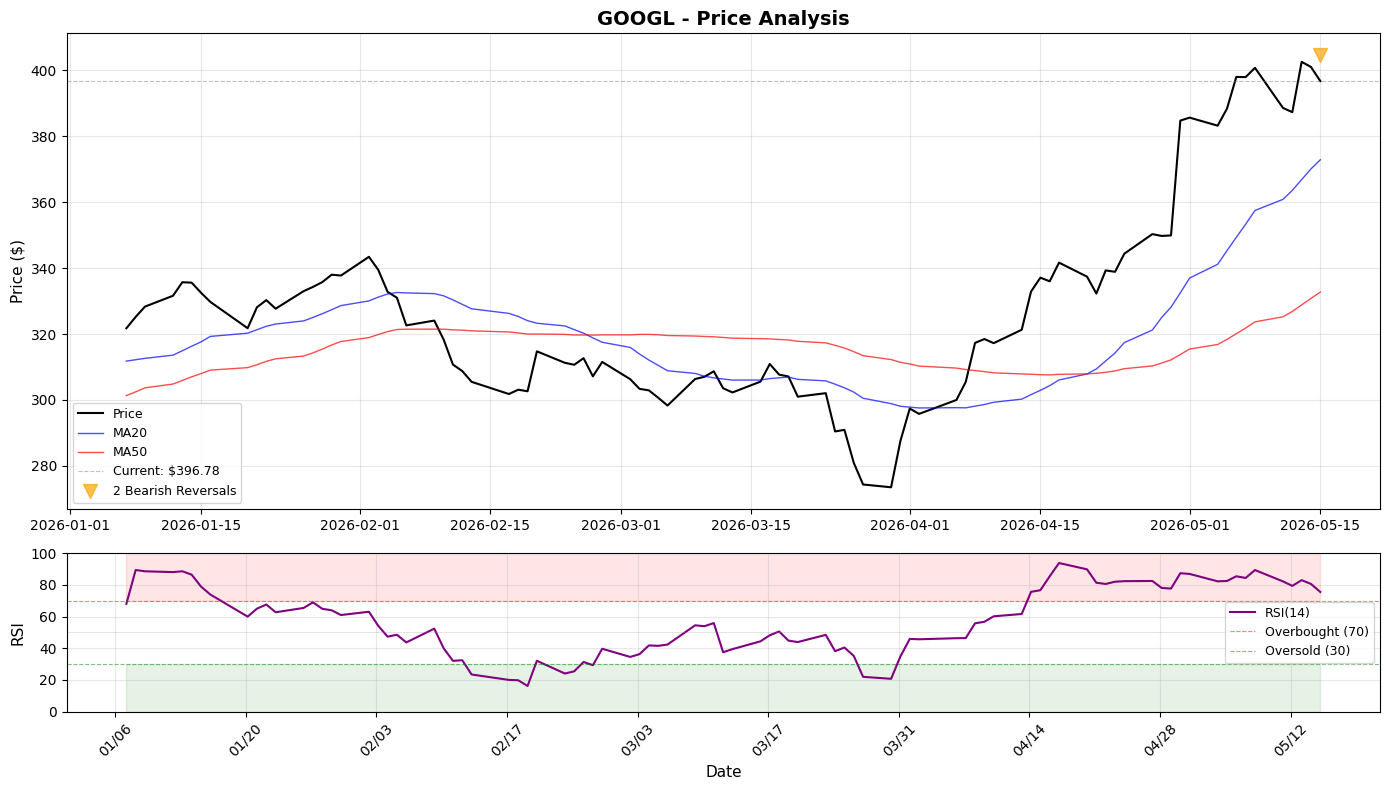


 SCANNING: XLF

 ── DAILY TIMEFRAME ──
 Price       : $51.1
 RSI (14)    : 39.1
 Trend       : MIXED
 MA20        : $51.7 (-1.1%)
 MA50        : $50.6 (+1.0%)
 30d HV      : 12.8%
 IV Pctile   : 21.7th
 Best Expiry : 2026-06-30 (45 DTE)

 ── WEEKLY TIMEFRAME ──
 Weekly RSI  : 40.8
 Weekly Trend: MIXED
 MA10W       : $50.34 (+1.5%)
 MA20W       : $51.64 (-1.0%)

 ── REVERSAL WATCH ──
 Bullish signals:
   ✓ RSI bullish divergence — price down, momentum up

 ⚠ FILTERED: BUY CALL - ⚠ Weak alignment - consider passing

 ── SIGNALS [Conviction: NONE] ──
 No high-probability setup today


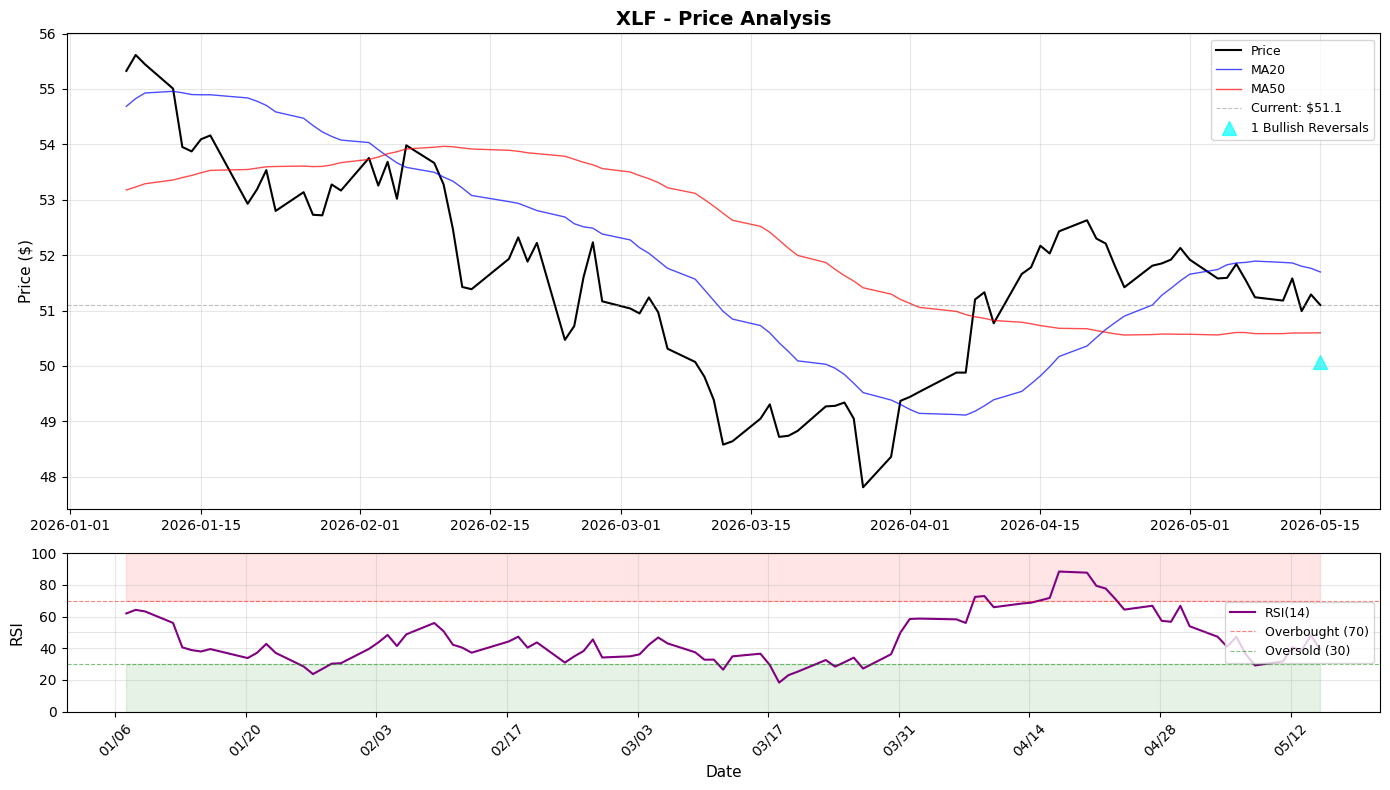


 SCAN COMPLETE



In [41]:
# Code Cell 8: Execute Scanner (v1.8 - Timezone fix)

if __name__ == "__main__":
    # Get local timestamp for display
    try:
        from datetime import datetime, timezone as dt_timezone
        from pytz import timezone as pytz_timezone

        utc_now = datetime.now(dt_timezone.utc)
        tz = pytz_timezone(TIMEZONE)
        local_time = utc_now.astimezone(tz)
        timestamp_display = local_time.strftime('%Y-%m-%d %H:%M %Z')
    except:
        timestamp_display = datetime.now().strftime('%Y-%m-%d %H:%M')

    print("\n" + "█"*62)
    print(" OPTIONS SCANNER — Directional Buys (45+ DTE)")
    print(f" Version: 1.8")
    print(f" Account: ${ACCOUNT_SIZE:,.2f} | "
          f"Risk: {RISK_PCT_MIN*100:.0f}%–{RISK_PCT_MAX*100:.0f}% per trade")
    print(f" Run date: {timestamp_display}")
    print("█"*62)

    for t in TICKERS:
        evaluate_ticker(t)

    print(f"\n{'='*62}")
    print(" SCAN COMPLETE")
    print(f"{'='*62}\n")